**Step 1** Dataset Loading


In [2]:
!nvidia-smi

Mon Aug 31 15:29:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  1


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10


(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = cifar10.load_data()


class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print("--- DATASET DIMENSIONS ---")
print(f"Train Images Shape: {X_train_raw.shape}")
print(f"Train Labels Shape: {y_train_raw.shape}")
print(f"Test Images Shape:  {X_test_raw.shape}")
print(f"Test Labels Shape:  {y_test_raw.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2064s 12us/step
--- DATASET DIMENSIONS ---
Train Images Shape: (50000, 32, 32, 3)
Train Labels Shape: (50000, 1)
Test Images Shape:  (10000, 32, 32, 3)
Test Labels Shape:  (10000, 1)


In [14]:

null_images = np.isnan(X_train_raw).sum() + np.isnan(X_test_raw).sum()
null_labels = np.isnan(y_train_raw).sum() + np.isnan(y_test_raw).sum()

expected_shape = (32, 32, 3)
corrupted_shapes = sum([1 for img in X_train_raw if img.shape != expected_shape])

valid_pixels = (X_train_raw.min() >= 0) and (X_train_raw.max() <= 255)


valid_labels = (y_train_raw.min() >= 0) and (y_train_raw.max() <= 9)

print("--- ADVANCED DATA INTEGRITY & CORRUPTION REPORT ---")
print(f"Missing/NaN Values:            {null_images + null_labels}")
print(f"Corrupted Image Shapes:        {corrupted_shapes}")
print(f"Valid Pixel Range (0-255):     {valid_pixels}")
print(f"Valid Label Range (0-9):       {valid_labels}")

if (null_images + null_labels == 0) and (corrupted_shapes == 0) and valid_pixels and valid_labels:
    print("\nResult: Dataset passed all corruption & integrity checks successfully!")

--- ADVANCED DATA INTEGRITY & CORRUPTION REPORT ---
Missing/NaN Values:            0
Corrupted Image Shapes:        0
Valid Pixel Range (0-255):     True
Valid Label Range (0-9):       True

Result: Dataset passed all corruption & integrity checks successfully!


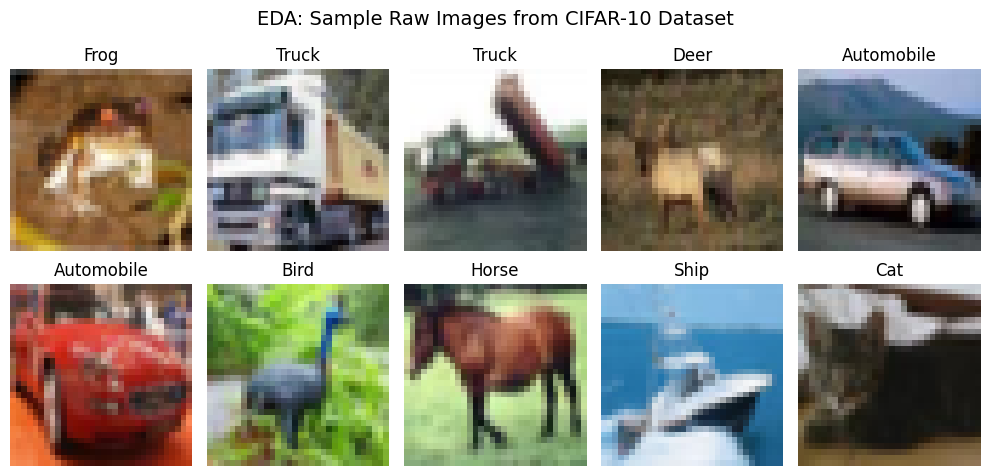

In [15]:

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_raw[i])
    plt.title(class_names[y_train_raw[i][0]])
    plt.axis('off')

plt.suptitle("EDA: Sample Raw Images from CIFAR-10 Dataset", fontsize=14)
plt.tight_layout()
plt.show()

**Step 2** Advanced EDA (Class Balance Bar Chart) & Normalization / Label Preprocessing par.

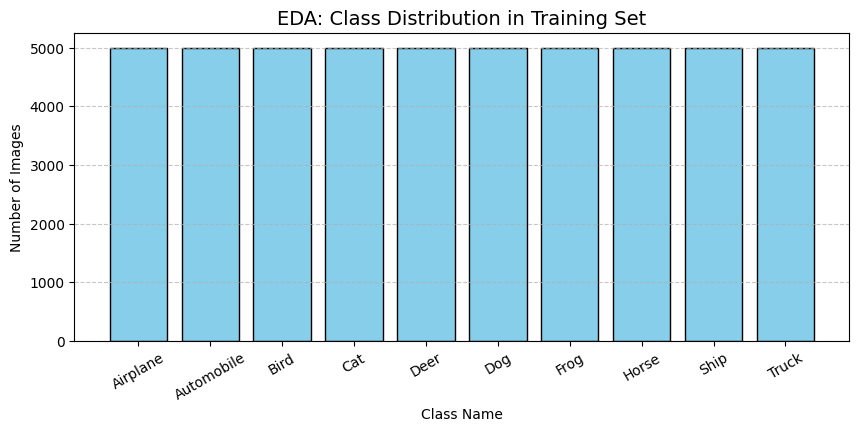

Class Balance Verification:
Airplane: 5000 samples
Automobile: 5000 samples
Bird: 5000 samples
Cat: 5000 samples
Deer: 5000 samples
Dog: 5000 samples
Frog: 5000 samples
Horse: 5000 samples
Ship: 5000 samples
Truck: 5000 samples


In [16]:

unique_classes, counts = np.unique(y_train_raw, return_counts=True)

plt.figure(figsize=(10, 4))
plt.bar([class_names[i] for i in unique_classes], counts, color='skyblue', edgecolor='black')
plt.title("EDA: Class Distribution in Training Set", fontsize=14)
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Class Balance Verification:")
for name, count in zip(class_names, counts):
    print(f"{name}: {count} samples")

In [17]:

X_train_norm = X_train_raw.astype('float32') / 255.0
X_test_norm = X_test_raw.astype('float32') / 255.0

print("--- PIXEL NORMALIZATION SUMMARY ---")
print(f"Original Pixel Range: [{X_train_raw.min()}, {X_train_raw.max()}]")
print(f"Normalized Pixel Range: [{X_train_norm.min():.1f}, {X_train_norm.max():.1f}]")
print(f"Data Type after Scaling: {X_train_norm.dtype}")

--- PIXEL NORMALIZATION SUMMARY ---
Original Pixel Range: [0, 255]
Normalized Pixel Range: [0.0, 1.0]
Data Type after Scaling: float32


In [18]:
from tensorflow.keras.utils import to_categorical


y_train_encoded = to_categorical(y_train_raw, 10)
y_test_encoded = to_categorical(y_test_raw, 10)

print("--- LABEL ENCODING SUMMARY ---")
print(f"Original Label Vector (Sample 0): {y_train_raw[0][0]} -> Class: {class_names[y_train_raw[0][0]]}")
print(f"One-Hot Encoded (Sample 0): {y_train_encoded[0]}")
print(f"Encoded Labels Shape: {y_train_encoded.shape}")

--- LABEL ENCODING SUMMARY ---
Original Label Vector (Sample 0): 6 -> Class: Frog
One-Hot Encoded (Sample 0): [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Encoded Labels Shape: (50000, 10)


**Step 3**: Data Augmentation & Train-Validation-Test Splitting par chalenge.

In [19]:
from sklearn.model_selection import train_test_split


X_train, X_val, y_train, y_val = train_test_split(
    X_train_norm, y_train_encoded,
    test_size=0.15,
    random_state=42,
    stratify=y_train_raw
)

X_test = X_test_norm
y_test = y_test_encoded

print("--- STRATIFIED DATASET SPLIT SUMMARY ---")
print(f"Training Set:   {X_train.shape[0]} samples ({X_train.shape})")
print(f"Validation Set: {X_val.shape[0]} samples  ({X_val.shape})")
print(f"Test Set:       {X_test.shape[0]} samples  ({X_test.shape})")

--- STRATIFIED DATASET SPLIT SUMMARY ---
Training Set:   42500 samples ((42500, 32, 32, 3))
Validation Set: 7500 samples  ((7500, 32, 32, 3))
Test Set:       10000 samples  ((10000, 32, 32, 3))


In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(X_train)

print("Status: Image Augmentation Pipeline successfully created & fitted on training set.")

Status: Image Augmentation Pipeline successfully created & fitted on training set.


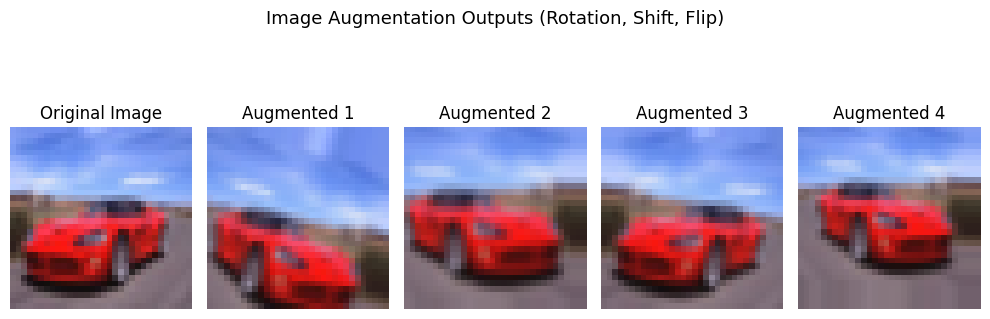

In [21]:

sample_img = X_train[0].reshape((1,) + X_train[0].shape)
aug_iter = datagen.flow(sample_img, batch_size=1)

plt.figure(figsize=(10, 4))

plt.subplot(1, 5, 1)
plt.imshow(X_train[0])
plt.title("Original Image")
plt.axis('off')
for i in range(4):
    aug_batch = next(aug_iter)
    plt.subplot(1, 5, i + 2)
    plt.imshow(aug_batch[0])
    plt.title(f"Augmented {i+1}")
    plt.axis('off')

plt.suptitle("Image Augmentation Outputs (Rotation, Shift, Flip)", fontsize=13)
plt.tight_layout()
plt.show()